In [65]:
import sys
sys.path.append("../../src/")
from common_imports import *
from scipy.integrate import solve_ivp
from numpy import conj
from numpy import linalg as la
import kibble_zurek as kz
from time import time
from joblib import Parallel, delayed
import numpy as np
import time_evolved_z_correlators as zz
#Load Pauli Matrices
s3,s1,s2 = array([[1,0],[0,-1]],dtype=complex),array([[0, 1],[1,0]],dtype=complex), array([[0,-1j],[1j,0]],dtype=complex)



In [26]:

def g(t,tau,alpha=1):
    """
    Time Dependent g(t) with a potential nonlinearity in quench speed controlled by alpha.
    """
    return 1 - np.sign(t)*abs(t/tau)**(alpha)
#TFIM functions
def a(q,g):
    return g+ cos(q)
def b(q,g):
    return sin(q)
def w(q,g):
    return sqrt(g*g+2*g*cos(q)+1)
def BdG(q,g):
    return -2*(a(q,g)*s3+b(q,g)*s2)
###

def BdG_stationary_evolve(t,U,g,q):
    return -1j*BdG(q,g)@U
       

def evolve_mode(q,g0,gf,t_eval):
    V0 = la.eigh(BdG(q, g0))[1][:, 1]
    sol = solve_ivp(
        BdG_stationary_evolve,
        [t_eval[0], t_eval[-1]],
        V0,
        args=(gf,q),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05,
    )
    return sol.y[0], sol.y[1]

def landau_states(L,g0,gf,t_eval):
    n = np.arange(0, L // 2)
    k = (2 * n + 1) * pi / L

    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(evolve_mode)(q, g0, gf, t_eval) for q in k
    )

    us, vs = map(np.array, zip(*results))

    states = [[us[:, i], vs[:, i], k] for i in range(len(t_eval))]
    return states, t_eval


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


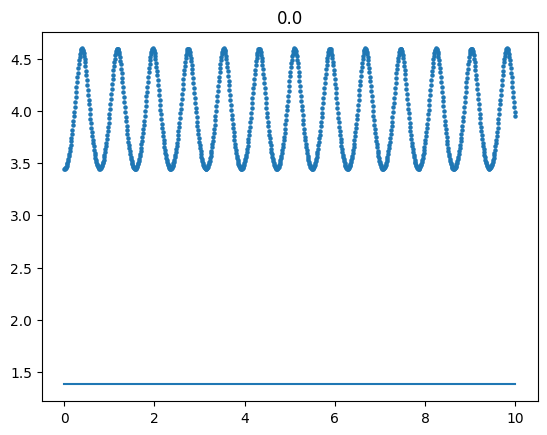

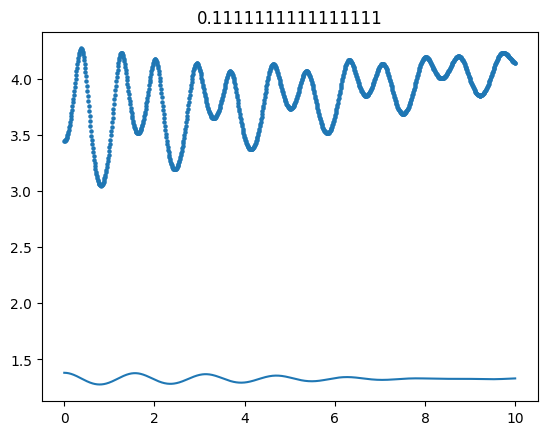

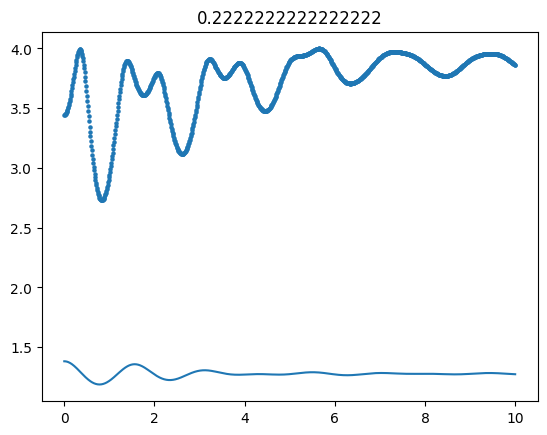

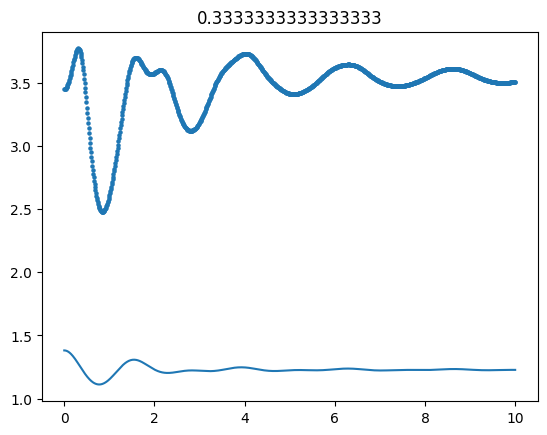

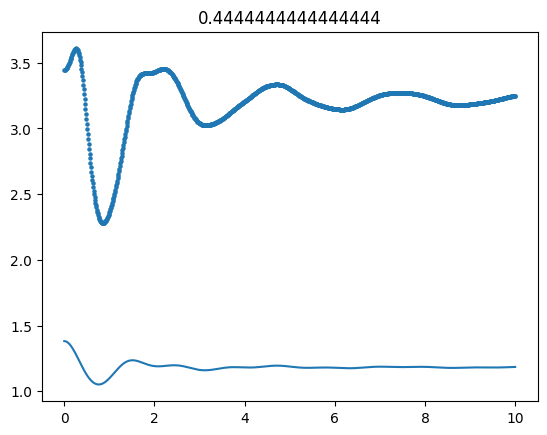

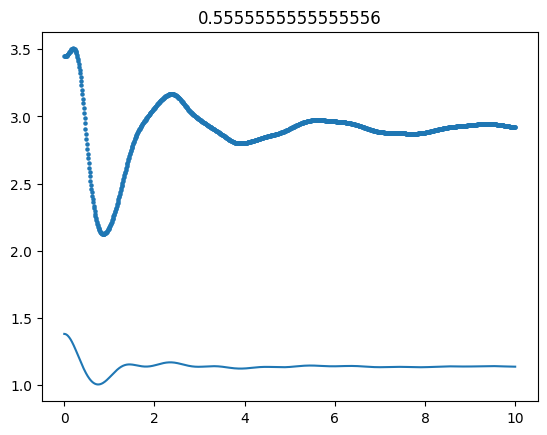

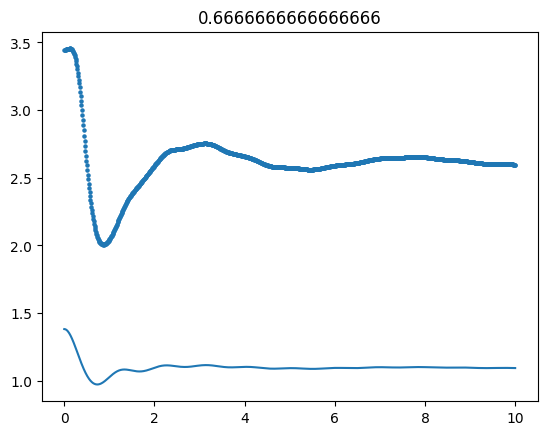

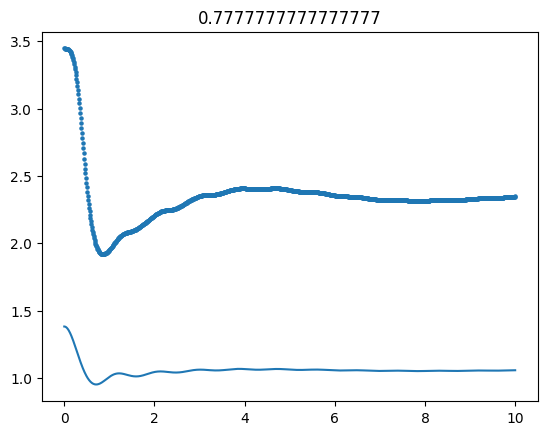

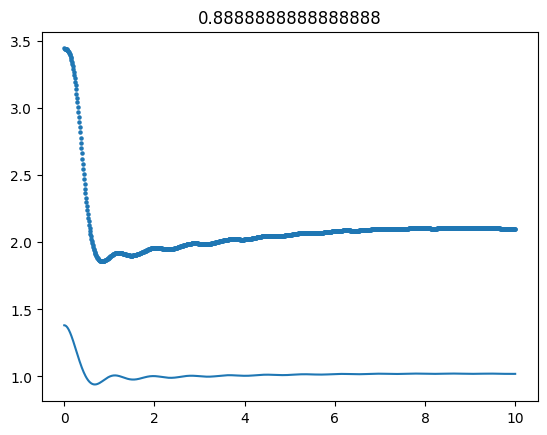

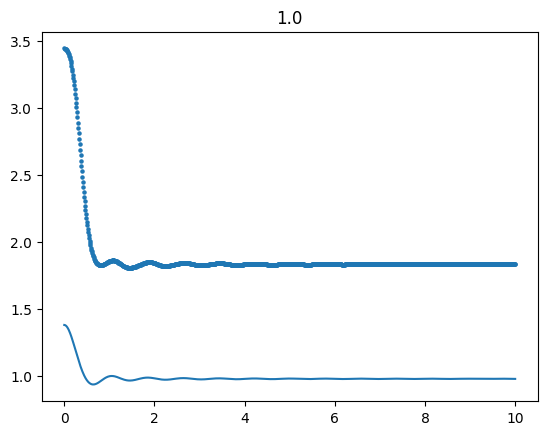

In [63]:
g0= 100
for gf in np.linspace(0,1,10):
    t_eval = np.linspace(0,10,1000)
    states,t_eval= landau_states(100,g0,gf,t_eval)
    dat=[]
    dat2=[]
    for s in states:
        dat.append(kz.P_n(2,s))
        dat2.append(kz.P_n(5,s))
    dat = array(dat)
    dat2 = array(dat2)
    plot(t_eval,-log(dat))
    title(f"{gf}")
    scatter(t_eval,-log(dat2),s=5)
    show()

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


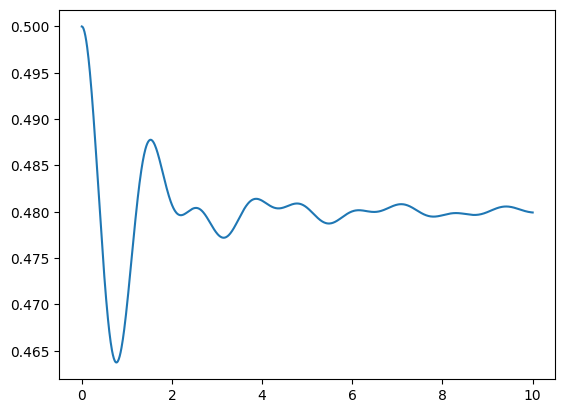